M2R Project — Shared starter module
Brownian motion, SDEs, and the path to SPDEs

Conventions (use these everywhere so our code stays consistent):
- Time grid:   numpy array of length N+1, with t[0]=0, t[N]=T
- BM paths:    shape (M, N+1), W[:, 0] = 0, M = number of Monte Carlo samples
- Randomness:  pass an `rng = np.random.default_rng(seed)` for reproducibility
- Drift / diffusion callables: f(t, x) and g(t, x), vectorised over x

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Core Utilities

In [2]:
def make_grid(T, N):
    """Uniform time grid on [0, T] with N+1 nodes."""
    return np.linspace(0.0, T, N + 1)

In [3]:
def simulate_bm(T, N, M=1, rng=None):
    """
    Simulate M independent scalar Brownian paths on [0, T] with N steps.

    Returns
    -------
    t : (N+1,) array
    W : (M, N+1) array, W[:, 0] = 0
    """
    rng = np.random.default_rng() if rng is None else rng
    t = make_grid(T, N)
    dt = T / N
    dW = rng.normal(0.0, np.sqrt(dt), size=(M, N))
    W = np.concatenate([np.zeros((M, 1)), np.cumsum(dW, axis=1)], axis=1)
    return t, W

In [4]:
def euler_maruyama(f, g, X0, T, N, M=1, rng=None, return_dW=False):
    """
    Solve  dX_t = f(t, X_t) dt + g(t, X_t) dW_t,  X_0 = X0,  by Euler-Maruyama.

    Parameters
    ----------
    f, g : callables (t: float, x: (M,) array) -> (M,) array
    X0   : scalar (broadcast) or (M,) array of initial values

    Returns
    -------
    t : (N+1,) array
    X : (M, N+1) array
    (optionally also dW : (M, N) array, the BM increments used)
    """
    rng = np.random.default_rng() if rng is None else rng
    t = make_grid(T, N)
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = rng.normal(0.0, np.sqrt(dt), size=(M, N))
    for n in range(N):
        X[:, n + 1] = X[:, n] + f(t[n], X[:, n]) * dt + g(t[n], X[:, n]) * dW[:, n]
    return (t, X, dW) if return_dW else (t, X)

Standard test SDEs (where the closed form solutions are known so these can be used as benchmarks)

In [5]:
def ou(theta, mu, sigma):
    """Ornstein-Uhlenbeck: dX = theta*(mu - X) dt + sigma dW."""
    return (lambda t, x: theta * (mu - x),
            lambda t, x: sigma * np.ones_like(x))

In [6]:
def gbm(mu, sigma):
    """Geometric BM: dX = mu*X dt + sigma*X dW. Exact: X_t = X_0 exp((mu - sigma^2/2)t + sigma W_t)."""
    return (lambda t, x: mu * x,
            lambda t, x: sigma * x)

In [7]:
def gbm_exact(X0, mu, sigma, t, W):
    """Closed-form GBM path, given the same BM W used in the simulation."""
    return X0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

How we divy up the code stuff... (decided by claude not me)

DANIEL:
  - strong_error(scheme, exact, ...)  : compare X^{dt} vs reference at T
  - weak_error(...)                   : compare E[phi(X_T)] vs E[phi(X_T^{exact})]
  - log-log plot of error vs dt, recover slopes 1/2 and 1

YUVRAJ:
  - simulate_bm_multi(d, T, N, M, ...) : d-dimensional BM, shape (M, d, N+1)
  - euler_maruyama_vec(f, G, X0, ...)  : G returns (M, d, m) matrix, dW is (M, m)
  - milstein(f, g, gprime, ...)        : add the 0.5 * g * g' * (dW^2 - dt) term

NATHAN:
  - heat_fd(u0, T, Nx, Nt)  : explicit finite-difference solver, mind CFL
  - heat_spectral(u0, T, Nt, K_modes)  : project onto sin basis, evolve coeffs
  - validation against u(t,x) = exp(-pi^2 t) sin(pi x)

These will all meet at: stochastic heat equation
du = u_xx dt + sigma dW_t   on [0,1], Dirichlet BCs
which in the sin basis becomes a decoupled system of OU SDEs
dg_n = -(n pi)^2 g_n dt + sigma dw_n,    n = 1, 2, ...
i.e. Yuvraj's vector SDE engine evolving Nathan's modes, validated by Daniel's convergence machinery.

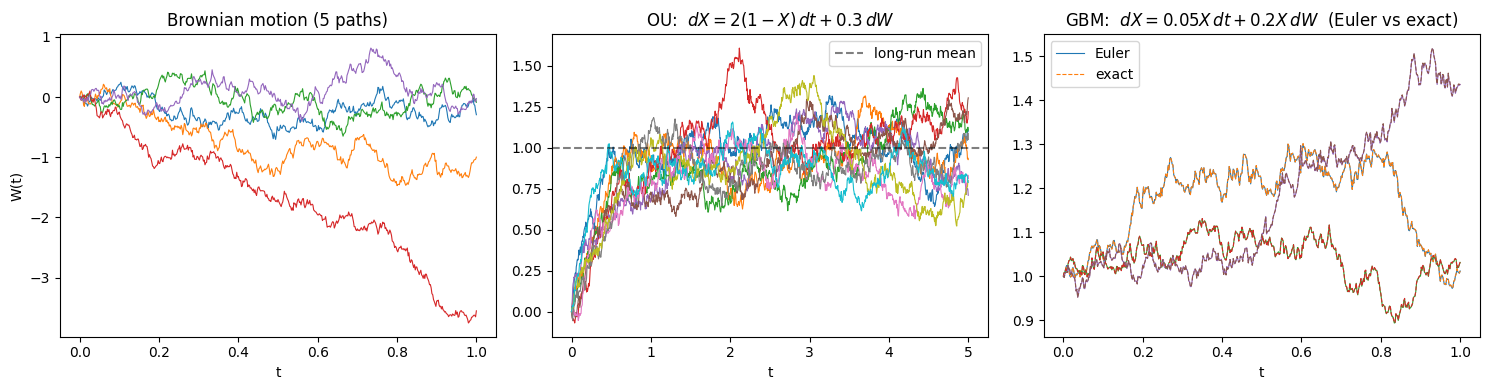

Saved figure to m2r_overview.png


In [8]:
# Main file to see everything running
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Brownian motion
t, W = simulate_bm(T=1.0, N=500, M=5, rng=rng)
axes[0].plot(t, W.T, lw=0.8)
axes[0].set_title("Brownian motion (5 paths)")
axes[0].set_xlabel("t"); axes[0].set_ylabel("W(t)")

# (2) Ornstein-Uhlenbeck, mean-reverting to mu = 1
f, g = ou(theta=2.0, mu=1.0, sigma=0.3)
t, X = euler_maruyama(f, g, X0=0.0, T=5.0, N=1000, M=10, rng=rng)
axes[1].plot(t, X.T, lw=0.8)
axes[1].axhline(1.0, color="k", ls="--", alpha=0.5, label="long-run mean")
axes[1].set_title(r"OU:  $dX = 2(1-X)\,dt + 0.3\,dW$")
axes[1].set_xlabel("t"); axes[1].legend()

# (3) Geometric BM, with Euler vs exact on the same BM driver
f, g = gbm(mu=0.05, sigma=0.2)
t, X, dW = euler_maruyama(f, g, X0=1.0, T=1.0, N=500, M=3, rng=rng, return_dW=True)
W_path = np.concatenate([np.zeros((3, 1)), np.cumsum(dW, axis=1)], axis=1)
X_exact = gbm_exact(X0=1.0, mu=0.05, sigma=0.2, t=t, W=W_path)
for i in range(3):
    axes[2].plot(t, X[i], lw=0.8, label="Euler" if i == 0 else None)
    axes[2].plot(t, X_exact[i], lw=0.8, ls="--", label="exact" if i == 0 else None)
axes[2].set_title(r"GBM:  $dX = 0.05X\,dt + 0.2X\,dW$  (Euler vs exact)")
axes[2].set_xlabel("t"); axes[2].legend()

plt.tight_layout()
plt.savefig("m2r_overview.png", dpi=120)
plt.show()
print("Saved figure to m2r_overview.png")

In [ ]:
# Daniel
# strong error = how close the paths are so taking RMSE at each timestamp basically
# weak error = how close the distributions are so taking the difference in expectation of the two paths
# theory from Euler-Maruyama says the strong error order should be 1/2, and the weak 1

def _bm_from_increments(dW):
    M = dW.shape[0]
    return np.concatenate([np.zeros((M, 1)), np.cumsum(dW, axis=1)], axis=1)


def strong_error(scheme, exact, T, N, M, rng=None, p=2):
    rng = np.random.default_rng() if rng is None else rng
    t, X, dW = scheme(T, N, M, rng)
    X_ref = exact(t, _bm_from_increments(dW))
    diff = np.abs(X[:, -1] - X_ref[:, -1])
    return float(np.mean(diff**p) ** (1.0 / p))


def weak_error(scheme, exact, phi, T, N, M, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    t, X, dW = scheme(T, N, M, rng)
    X_ref = exact(t, _bm_from_increments(dW))
    return float(abs(np.mean(phi(X[:, -1])) - np.mean(phi(X_ref[:, -1]))))


def convergence_study(error_fn, Ns, T):
    Ns = np.asarray(list(Ns))
    dts = T / Ns
    errs = np.array([error_fn(int(N)) for N in Ns])
    slope, intercept = np.polyfit(np.log(dts), np.log(errs), 1)
    return dts, errs, float(slope), float(intercept)


def loglog_convergence(dts, errs, slope, label, ref_order, ax=None):
    ax = plt.gca() if ax is None else ax
    ax.loglog(dts, errs, "o-", label=f"{label}  (fitted slope {slope:.2f})")
    c = errs[-1] / dts[-1] ** ref_order            # anchor the guide at the finest dt
    ax.loglog(dts, c * dts ** ref_order, "k--", alpha=0.6,
              label=fr"reference slope {ref_order:g}")
    ax.set_xlabel(r"$\Delta t$")
    ax.set_ylabel("error")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    return ax

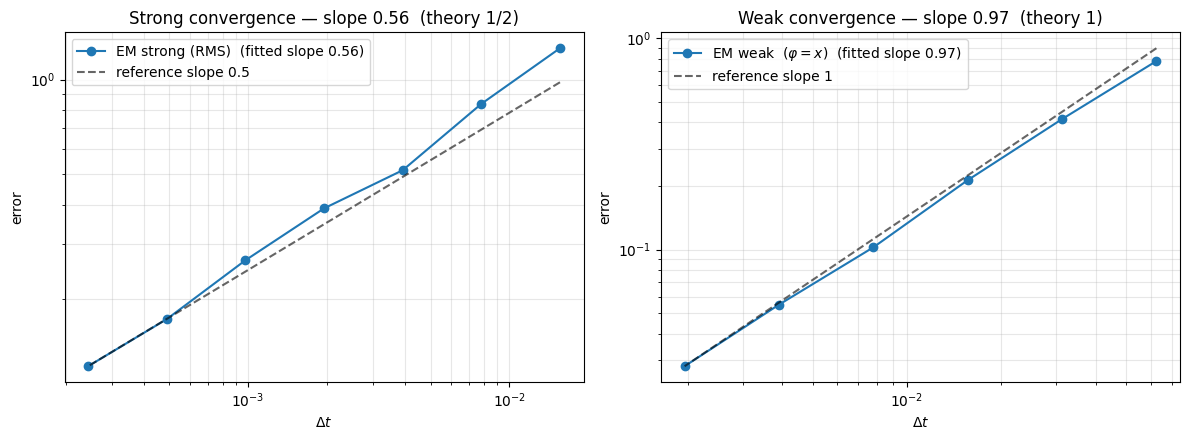

strong slope = 0.556   (Euler–Maruyama theory: 1/2)
weak   slope = 0.966   (Euler–Maruyama theory: 1)


In [ ]:
#results
X0, mu, sigma, T = 1.0, 2.0, 1.0, 1.0
f, g = gbm(mu, sigma)
scheme = lambda T, N, M, rng: euler_maruyama(f, g, X0, T, N, M=M, rng=rng, return_dW=True)
exact  = lambda t, W: gbm_exact(X0, mu, sigma, t, W)

Ns_strong = [64, 128, 256, 512, 1024, 2048, 4096]   # dt from 1/64 down to 1/4096
Ns_weak   = [16, 32, 64, 128, 256, 512]

ds, es, slope_s, _ = convergence_study(
    lambda N: strong_error(scheme, exact, T, N, M=6000, rng=np.random.default_rng(0)),
    Ns_strong, T)
dw, ew, slope_w, _ = convergence_study(
    lambda N: weak_error(scheme, exact, lambda x: x, T, N, M=30000, rng=np.random.default_rng(10)),
    Ns_weak, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
loglog_convergence(ds, es, slope_s, "EM strong (RMS)", ref_order=0.5, ax=axes[0])
axes[0].set_title(f"Strong convergence — slope {slope_s:.2f}  (theory 1/2)")
loglog_convergence(dw, ew, slope_w, r"EM weak  ($\varphi=x$)", ref_order=1.0, ax=axes[1])
axes[1].set_title(f"Weak convergence — slope {slope_w:.2f}  (theory 1)")
plt.tight_layout()
plt.savefig("m2r_convergence.png", dpi=120)
plt.show()

print(f"strong slope = {slope_s:.3f}   (Euler–Maruyama theory: 1/2)")
print(f"weak   slope = {slope_w:.3f}   (Euler–Maruyama theory: 1)")

In [12]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib import cbook, cm
from mpl_toolkits.mplot3d import axes3d
import scipy
from scipy.fft import dst, idst

def heat_fd(u0, T, Nx, Nt, rng, k, var):
    # Initialize solution matrix
    u = np.zeros((Nt,Nx + 1))
    u[0] = [u0(x / Nx) for x in range(Nx + 1)]
    
    x = np.linspace(0, T, Nt)
    y = np.linspace(0, 1, Nx + 1)
    X, Y = np.meshgrid(x, y)

    # Iterate over time
    dt = T/Nt
    dx = 1/Nx
    for t in range(1, Nt):
        u[t][0] = 0
        u[t][Nx] = 0
        for x in range(1, Nx):
            wt = rng.normal(0, math.sqrt(var * dt / dx))
            u[t][x] = u[t-1][x] + k * (dt / (dx ** 2))*(u[t-1][x-1] - 2*u[t-1][x] + u[t-1][x+1]) + wt

    return X, Y, u

# du = (d^2u/dx^2)dt + g(t)dWt
def heat_spectral(u0, T, Nt, Nx, K_modes, rng, d, var, g, Q): 
    # Initialize solution matrix
    u = np.zeros((Nt,Nx + 1))
    u[0] = [u0(x / Nx) for x in range(Nx + 1)]
    
    x = np.linspace(0, T, Nt)
    y = np.linspace(0, 1, Nx + 1)
    X, Y = np.meshgrid(x, y)

    dt = T/Nt
    dx = 1/Nx

    # Project to modes
    a = dst(u[0], n=K_modes, type=1, norm='ortho')
    
    # Iterate over time
    for t in range(Nt):
        wt = rng.multivariate_normal(np.zeros((K_modes,)), var * dt * Q) # idk what to put here tbh
        
        # Update Coeffs
        a = [a[k] * np.exp(-2*d*((k+1)*np.pi)**2 * dt) + g(t*dt)*wt[k] for k in range(K_modes)]
    
        # Compute new u
        u[t] = idst(a, n=Nx+1, type=1, norm='ortho')


    return X, Y, u

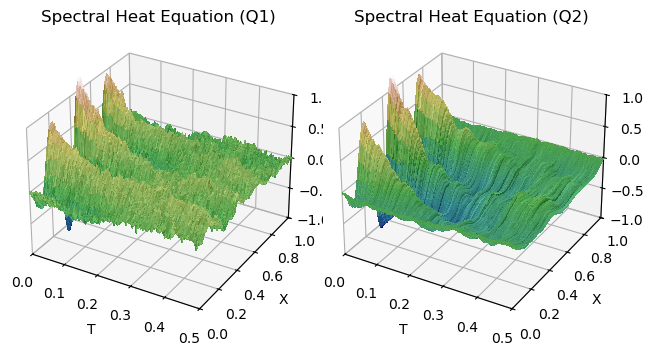

In [24]:
# Heat Equation
def init(x):
    return 5*x*(x-1)*math.sin(23*x)

def g(x):
    return 1 #np.exp(-x)

def random_Q():
    data = [[np.random.uniform(0, 1) for i in range(K_modes)] for j in range(K_modes)]
    Q = np.cov(data) * 10
    eigenvalues = np.linalg.eigvals(Q)
    return Q

rng = np.random.default_rng(67)

T = 2
T1 = 0.5
K_modes = 50

def trace_class_Q():
    Q = np.zeros((K_modes, K_modes))
    for i in range(K_modes):
        Q[i][i] = 10/(i+1)**2

    return Q

random_Q = random_Q()

# print(random_Q)

X, Y, u = heat_fd(u0=init, T=T, Nt=1000, Nx=15, rng=rng, k=0.01, var=0.01)
X1, Y1, u1 = heat_spectral(u0=init, T=T1, Nt=1000, Nx=50, rng=rng, K_modes=K_modes, d=0.01, var=0.5, g=g, Q=np.identity(K_modes))
X2, Y2, u2 = heat_spectral(u0=init, T=T1, Nt=1000, Nx=50, rng=rng, K_modes=K_modes, d=0.01, var=0.5, g=g, Q=trace_class_Q())


# Set up plot
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection='3d'))

ls = col.LightSource(270, 45)
# To use a custom hillshading mode, override the built-in shading and pass
# in the rgb colors of the shaded surface calculated from "shade".
rgb = ls.shade(u.T, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')
rgb1 = ls.shade(u1.T, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')
rgb2 = ls.shade(u2.T, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')
plot1 = axs[0].plot_surface(X1, Y1, u1.T, rstride=1, cstride=1, facecolors=rgb1,
                       linewidth=0, antialiased=False, shade=False)
plot2 = axs[1].plot_surface(X2, Y2, u2.T, rstride=1, cstride=1, facecolors=rgb2,
                       linewidth=0, antialiased=False, shade=False)


axs[0].set(xlim=(0, T1), ylim=(0, 1), zlim=(-1, 1), xlabel='T', ylabel='X', zlabel='H')
axs[1].set(xlim=(0, T1), ylim=(0, 1), zlim=(-1, 1), xlabel='T', ylabel='X', zlabel='H')
axs[0].set_title("Spectral Heat Equation (Q1)")
axs[1].set_title("Spectral Heat Equation (Q2)")

plt.tight_layout()
plt.show()